# Aula 1 — Fundamentos de Ciência de Dados e Machine Learning

Bem-vindo(a) ao curso **Introdução à Ciência de Dados e IA**! Esta é a nossa
primeira aula e ela tem um objetivo claro: construir o **mapa mental** da área e,
em seguida, **treinar o nosso primeiro modelo de Machine Learning do zero**.

> **Objetivo da aula:** ao final, você terá percorrido o fluxo de um projeto de
> dados e construído, com as próprias mãos, uma **regressão linear** implementada
> em **NumPy** e treinada com **Gradient Descent**.

A aula está dividida em dois blocos, separados pelo intervalo:

1. **Bloco 1 — Introdução à Ciência de Dados**: onde estamos, o que são dados e o
   que é Machine Learning.
2. **Bloco 2 — Regressão Linear e Gradient Descent**: a matemática mínima
   necessária e a implementação do nosso primeiro modelo.

> **Como usar este notebook:** acompanhe **célula a célula** junto do instrutor.
> Rode o código enquanto avançamos e não tenha medo de alterar valores para
> experimentar. Os exercícios extra estão no notebook de exercícios da aula.


## Bloco 1 — Introdução à Ciência de Dados


### O que é Ciência de Dados?

Ciência de Dados é o campo que extrai **conhecimento** e **decisões** a partir de
dados. Ela combina três ingredientes:

- **programação** (para manipular dados e treinar modelos);
- **estatística e matemática** (para medir, generalizar e otimizar);
- **conhecimento do domínio** (para fazer as perguntas certas).

> **Conceito:** fazer Ciência de Dados não é "usar um modelo"; é **resolver um
> problema** transformando dados em uma resposta útil.


### Não é só Ciência de Dados

A área de dados costuma ser dividida em papéis com focos diferentes:

| Área | Foco principal | Pergunta típica |
| --- | --- | --- |
| **Data Analysis** | Interpretar dados já organizados | "O que aconteceu e por quê?" |
| **Data Engineering** | Construir o caminho dos dados | "Como os dados chegam limpos e no lugar certo?" |
| **Data Science** | Modelar e prever a partir dos dados | "O que vai acontecer / qual a melhor decisão?" |

> **Nota do instrutor:** na prática esses papéis se misturam. Hoje vamos passar por
> todos: coletar, limpar, explorar e modelar.


### IA, Machine Learning e Deep Learning

Esses três termos não são sinônimos — eles formam camadas:

```
Inteligência Artificial  -> qualquer sistema que executa tarefas "inteligentes"
   |
   +-- Machine Learning  -> aprende padrões a partir de dados, em vez de ser programado regra por regra
          |
          +-- Deep Learning -> Machine Learning com redes neurais profundas
```

> **Simplificação:** no Machine Learning nós **não escrevemos a regra**; nós
> mostramos exemplos e o modelo **descobre a regra**.


### O que são dados? E o que fazemos com eles?

Dados são **observações do mundo** organizadas em uma tabela: cada **linha** é um
exemplo (um pedido, um cliente) e cada **coluna** é uma característica (*feature*).

Um projeto de dados costuma seguir este fluxo:

```
coleta -> limpeza (cleaning) -> ETL/ELT -> EDA -> feature engineering -> modelo
```

- **ETL/ELT**: *Extract, Transform, Load* — mover e padronizar dados entre sistemas.
  *ELT* carrega antes de transformar; *ETL* transforma antes de carregar.
- **Data Cleaning**: lidar com valores ausentes, duplicados, tipos errados e outliers.
- **EDA** (*Análise Exploratória de Dados*): resumir e visualizar para entender os dados.
- **Feature Engineering**: criar/transformar colunas para ajudar o modelo a aprender.

> **Conceito:** "garbage in, garbage out". Um modelo só é tão bom quanto os dados
> que recebe — por isso limpamos e exploramos **antes** de modelar.


### Preparando o ambiente

Antes de mexer nos dados, importamos as bibliotecas que vamos usar. Mantemos
poucas dependências de propósito:

- **pandas** — tabelas;
- **numpy** — matemática e vetores (usaremos para implementar o modelo);
- **matplotlib** e **seaborn** — gráficos.


In [1]:
import pandas as pd                  # manipulação de dados (tabelas)
import numpy as np                   # matemática e vetores
import matplotlib.pyplot as plt      # gráficos
import seaborn as sns                # gráficos estatísticos (em cima do matplotlib)

sns.set_theme(style="whitegrid")     # estilo padrão dos nossos gráficos
pd.set_option("display.max_columns", 50)


### Carregando os dados

Vamos carregar os arquivos de dados. O código abaixo procura a pasta `archive`
em alguns caminhos possíveis, para funcionar tanto rodando da **raiz do
repositório** quanto de **dentro** de `aulas/aula01`.


In [2]:
from pathlib import Path

# Procura a pasta de dados subindo a partir do diretório atual.
# Assim o notebook funciona rodando da raiz do repositório, de aulas/aula01
# ou de outra pasta (como referencia-aulas/).
data_dir = None
for base in [Path.cwd(), *Path.cwd().parents]:
    for candidate in (base / "aulas/aula01/archive", base / "aula01/archive", base / "archive"):
        if candidate.exists():
            data_dir = candidate
            break
    if data_dir is not None:
        break

print("Diretório dos dados:", data_dir)

dfPayments = pd.read_csv(data_dir / "olist_order_payments_dataset.csv")
dfProducts = pd.read_csv(data_dir / "olist_products_dataset.csv")
dfOrders   = pd.read_csv(data_dir / "olist_orders_dataset.csv")
dfItems    = pd.read_csv(data_dir / "olist_order_items_dataset.csv")

print("orders   :", dfOrders.shape)
print("items    :", dfItems.shape)
print("products :", dfProducts.shape)
print("payments :", dfPayments.shape)


Diretório dos dados: /home/dopp/projects/DataScience-INFOESTE2026/aulas/aula01/archive


orders   : (99441, 8)
items    : (112650, 7)
products : (32951, 9)
payments : (103886, 5)


### O dataset: e-commerce Olist

Vamos usar o **Brazilian E-Commerce Public Dataset (Olist)**: pedidos reais de uma
loja virtual brasileira, divididos em várias tabelas que precisam ser **combinadas**.

| Tabela | O que contém |
| --- | --- |
| `olist_orders_dataset` | informações e status de cada pedido |
| `olist_order_items_dataset` | itens de cada pedido (preço, frete) |
| `olist_products_dataset` | características físicas dos produtos |
| `olist_order_payments_dataset` | pagamentos de cada pedido |

> **Nota do instrutor:** repare que cada arquivo tem uma **chave** (ex.: `order_id`,
> `product_id`). Juntar tabelas por essas chaves é o famoso **JOIN**.


### Juntando as tabelas (JOIN)

Vamos combinar as tabelas em um único `DataFrame`.

Antes, um detalhe de **Data Engineering**: um pedido pode ter **vários pagamentos**
(cartão + voucher, por exemplo). Se juntássemos direto, um mesmo item apareceria
várias vezes. Por isso **agregamos** os pagamentos por pedido (somamos o valor).


In [3]:
# Pagamentos podem ter várias linhas por pedido -> agregamos por pedido (soma)
payments_agg = (
    dfPayments
    .groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

# JOIN: itens + produtos + pedidos + pagamentos (agregados)
df = (
    dfItems
    .merge(dfProducts, on="product_id", how="inner")
    .merge(dfOrders,   on="order_id",   how="inner")
    .merge(payments_agg, on="order_id", how="inner")
)

print("Formato final:", df.shape)
df.head()


Formato final: (112647, 23)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,218.04


In [4]:
# Tipos das colunas, quantos valores não nulos existem, uso de memória...
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 112647 entries, 0 to 112646
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112647 non-null  str    
 1   order_item_id                  112647 non-null  int64  
 2   product_id                     112647 non-null  str    
 3   seller_id                      112647 non-null  str    
 4   shipping_limit_date            112647 non-null  str    
 5   price                          112647 non-null  float64
 6   freight_value                  112647 non-null  float64
 7   product_category_name          111044 non-null  str    
 8   product_name_lenght            111044 non-null  float64
 9   product_description_lenght     111044 non-null  float64
 10  product_photos_qty             111044 non-null  float64
 11  product_weight_g               112629 non-null  float64
 12  product_length_cm              112629 non

In [5]:
# Estatísticas das variáveis numéricas que nos interessam
df[["price", "freight_value", "product_weight_g", "payment_value"]].describe()


,price,freight_value,product_weight_g,payment_value
count,112647.000000,112647.000000,112629.000000,112647.000000
mean,120.655754,19.990777,2093.701178,180.281186
std,183.635958,15.806368,3751.642601,272.849042
min,0.850000,0.000000,0.000000,9.590000
25%,39.900000,13.080000,300.000000,65.670000
50%,74.990000,16.260000,700.000000,114.440000
75%,134.900000,21.150000,1800.000000,195.390000
max,6735.000000,409.680000,40425.000000,13664.080000


### EDA: entendendo os dados antes de modelar

Antes de qualquer modelo, precisamos **olhar** os dados. Vamos começar pelas
colunas numéricas e ver como estão distribuídas.

> **Conceito (EDA):** *Análise Exploratória de Dados* é o momento de fazer
> perguntas simples (mínimo, máximo, média, formato da distribuição) **antes** de
> investir tempo em modelagem.


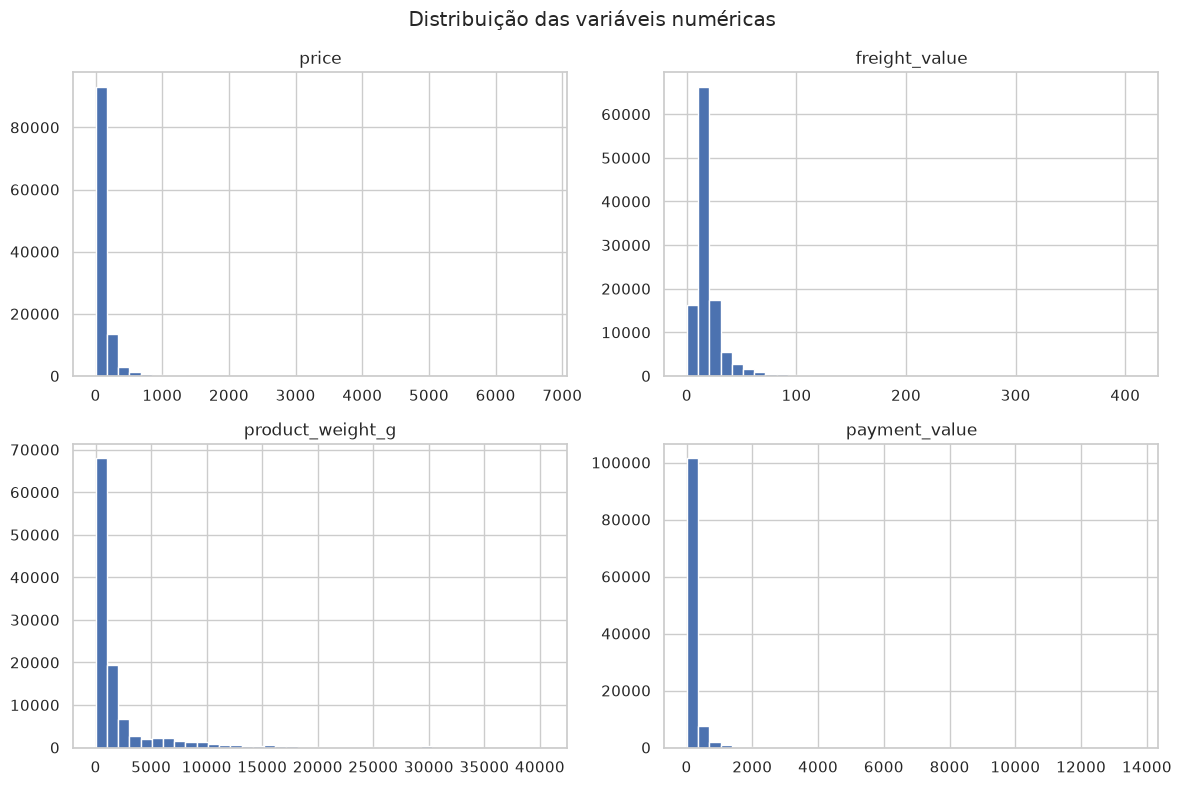

In [6]:
# Distribuição de cada variável numérica (histogramas)
numeric_cols = ["price", "freight_value", "product_weight_g", "payment_value"]

df[numeric_cols].hist(figsize=(12, 8), bins=40, edgecolor="white")
plt.suptitle("Distribuição das variáveis numéricas")
plt.tight_layout()
plt.show()


Os histogramas mostram que as variáveis são **assimétricas** (poucos valores
muito altos à direita) — algo comum em dados reais de e-commerce. Repare em especial
no `price`: a maioria dos produtos é barata, mas uma **cauda longa** estica a
distribuição para a direita. Voltaremos nisso ao preparar o alvo.


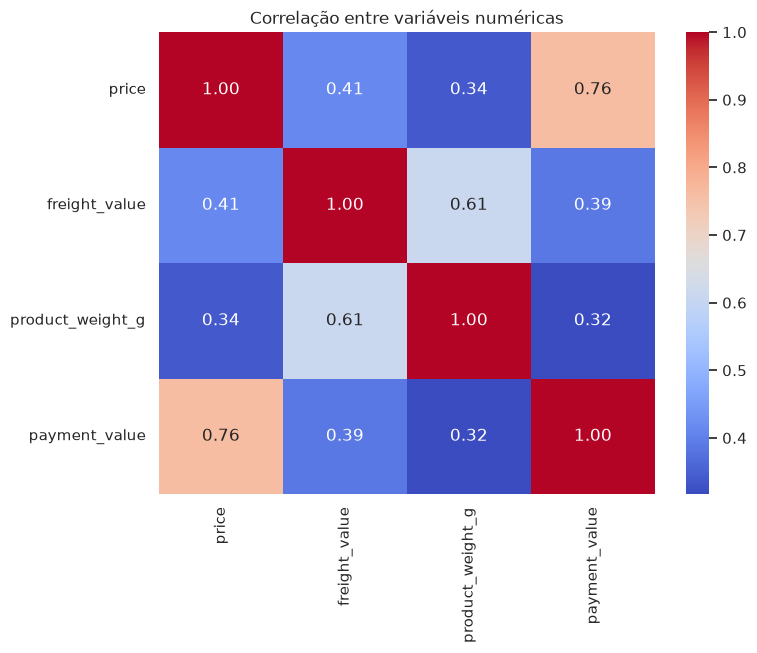

In [7]:
# Correlação entre as variáveis numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre variáveis numéricas")
plt.show()


### Data Cleaning: valores ausentes e outliers

Dois problemas muito comuns antes de modelar:

1. **Valores ausentes** (*missing*): algumas linhas não têm todas as colunas.
2. **Outliers**: valores extremos que podem distorcer o modelo.

> **Conceito (outlier):** um valor muito distante do padrão dos demais. Um produto
> absurdamente pesado, por exemplo, pode "puxar" a reta para longe dele.

Vamos verificar e tratar os dois casos.


In [8]:
# 1) Valores ausentes entre as colunas que vamos usar
cols_interesse = ["product_weight_g", "freight_value", "price", "payment_value"]
print("Valores ausentes por coluna:")
print(df[cols_interesse].isna().sum())

# 2) Mantemos apenas linhas completas para essas colunas
df_clean = df[cols_interesse].dropna().copy()
print("\nLinhas antes:", len(df), "| depois de remover ausentes:", len(df_clean))


Valores ausentes por coluna:
product_weight_g    18
freight_value        0
price                0
payment_value        0
dtype: int64

Linhas antes: 112647 | depois de remover ausentes: 112629


In [9]:
# 3) Removemos outliers extremos de peso (acima do percentil 99)
#    O percentil 99 "corta" os 1% de valores mais altos de peso.
peso_limite = df_clean["product_weight_g"].quantile(0.99)
print("Limite de peso (p99):", peso_limite)

df_clean = df_clean[df_clean["product_weight_g"] <= peso_limite].copy()
print("Depois de remover outliers de peso:", len(df_clean))


Limite de peso (p99): 18250.0
Depois de remover outliers de peso: 111512


### Feature Engineering e divisão treino/teste

Vamos montar nosso problema de Machine Learning. A pergunta é:

> **"Dado o peso de um produto, quanto ele deve custar?"**

Isso faz sentido no mundo real: produtos maiores e mais pesados costumam ser
mais caros (mas nem sempre — veremos isso no diagnóstico).

- **Feature (entrada)** $x$: `product_weight_g` — peso do produto, em gramas.
- **Alvo (saída)** $y$: `price` — preço do produto, em R$.

> **Simplificação:** usamos **uma única** variável para começar. Modelos reais usam
> muitas — voltaremos nisso.

Em Machine Learning, **nunca** avaliamos o modelo nos mesmos dados em que ele
treinou: isso faria o modelo apenas "decorar". Por isso separamos **treino** e
**teste**.


In [10]:
from sklearn.model_selection import train_test_split

x = df_clean["product_weight_g"].to_numpy(dtype=float)  # feature de entrada
price = df_clean["price"].to_numpy(dtype=float)         # alvo: o preço

# 80% para treinar, 20% para testar. random_state garante que o resultado se repete.
x_train, x_test, price_train, price_test = train_test_split(
    x, price, test_size=0.2, random_state=42
)

print("Treino:", x_train.shape, "| Teste:", x_test.shape)


Treino: (89209,) | Teste: (22303,)


### Por que transformar o `price`? (Yeo-Johnson)

Vimos que o preço tem uma distribuição muito **assimétrica**: a maioria dos produtos
é barata, mas alguns custam milhares de reais. Essa cauda longa "espalha" os valores
e complica uma aula que quer focar no **mecanismo** do modelo.

Por isso aplicamos a transformação **Yeo-Johnson** (via `PowerTransformer`): ela
"puxa" os valores para uma distribuição mais **simétrica** e ainda padroniza
(média 0, desvio 1). A coluna resultante chamamos de **`price_adj`** (preço ajustado).

> **Atenção (importante):** essa transformação é **puramente para simplificar a aula**.
> Não é a única forma de lidar com dados assimétricos nem é sempre necessária — no
> mercado existem várias abordagens. Aqui ela serve só para deixar o problema mais
> "redondo" para aprendermos o mecanismo.


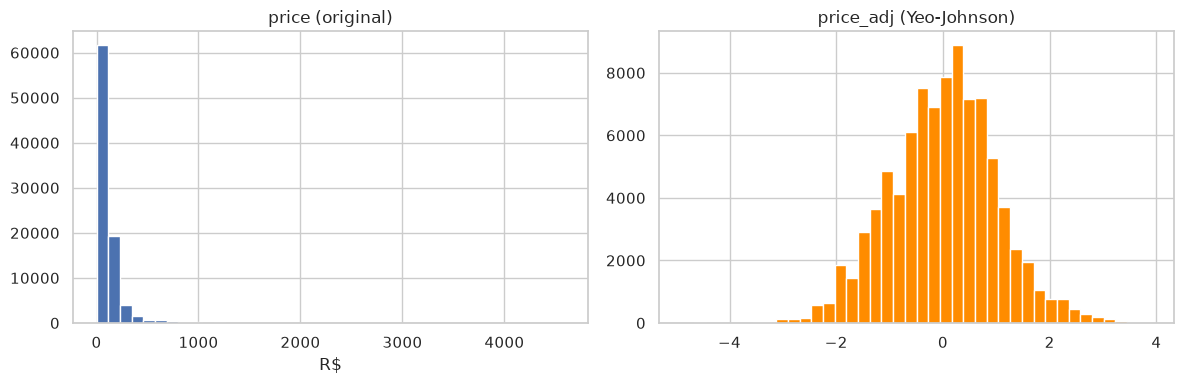

price     -> min 0.85 | máx 4590.00 (assimétrico)
price_adj -> média 0.000 | desvio 1.000


In [11]:
from sklearn.preprocessing import PowerTransformer

# Ajustamos a transformação APENAS no treino e depois aplicamos no teste (evita "vazamento").
pt = PowerTransformer(method="yeo-johnson", standardize=True)
price_adj_train = pt.fit_transform(price_train.reshape(-1, 1)).ravel()
price_adj_test  = pt.transform(price_test.reshape(-1, 1)).ravel()

# Daqui em diante, o nosso alvo é o preço ajustado.
y_train = price_adj_train
y_test  = price_adj_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(price_train, bins=40, edgecolor="white")
axes[0].set_title("price (original)")
axes[0].set_xlabel("R$")
axes[1].hist(price_adj_train, bins=40, edgecolor="white", color="darkorange")
axes[1].set_title("price_adj (Yeo-Johnson)")
plt.tight_layout()
plt.show()

print(f"price     -> min {price_train.min():.2f} | máx {price_train.max():.2f} (assimétrico)")
print(f"price_adj -> média {price_adj_train.mean():.3f} | desvio {price_adj_train.std():.3f}")


> **Fim do Bloco 1.**

Hora de uma pausa! Quando voltarmos, vamos transformar esses dados em um modelo.

---

## Bloco 2 — Regressão Linear e Gradient Descent


### Linearidade

Vamos olhar a relação entre peso e `price_adj` em um gráfico de dispersão (*scatter plot*).
Cada ponto é um item vendido.

> **Conceito (linearidade):** duas variáveis têm relação **linear** quando dá para
> aproximá-las por uma **reta**. Aumentar $x$ faz $y$ variar de forma
> aproximadamente proporcional.


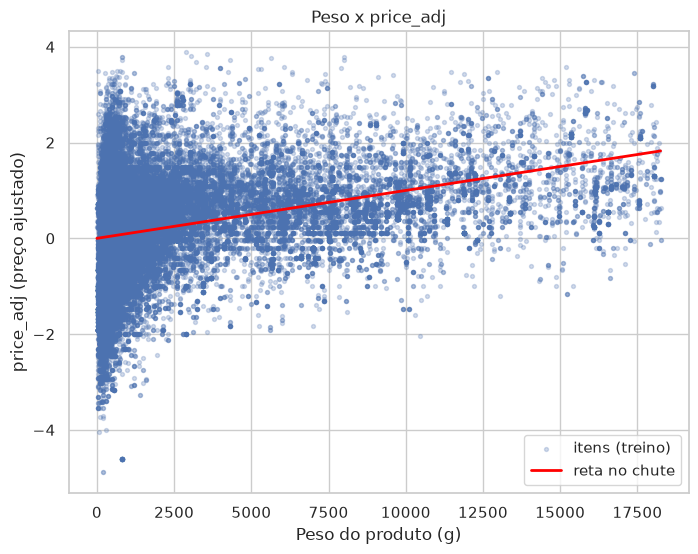

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, s=8, alpha=0.25, label="itens (treino)")

# Uma reta "no chute", só para ilustrar o que queremos encontrar
x_line = np.array([x_train.min(), x_train.max()])
plt.plot(x_line, 0.0001 * x_line, color="red", linewidth=2, label="reta no chute")

plt.xlabel("Peso do produto (g)")
plt.ylabel("price_adj (preço ajustado)")
plt.title("Peso x price_adj")
plt.legend()
plt.show()


### O modelo: uma reta

Nosso modelo é simplesmente uma **reta**:

$$\hat{y} = w\,x + b$$

- $w$ é o **peso** (*weight*) ou coeficiente angular — o quanto $y$ muda quando $x$ muda;
- $b$ é o **viés** (*bias*) ou intercepto — o valor de $y$ quando $x = 0$;
- $\hat{y}$ ("y chapéu") é a **previsão** do modelo.

> **Objetivo:** encontrar $w$ e $b$ que façam a reta passar o **mais perto
> possível** dos pontos. Mas "mais perto" precisa de uma medida — é aí que entra a
> função de custo.


### Erro, resíduo e a função de custo (MSE)

Para cada ponto, o **resíduo** é a diferença entre a previsão e o valor real:

$$r_i = \hat{y}_i - y_i$$

Precisamos resumir todos os resíduos em um único número. Se apenas somarmos, erros
positivos e negativos se cancelam. Por isso elevamos ao quadrado antes de tirar a média:

$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} \big(\hat{y}_i - y_i\big)^2$$

Essa é a **Mean Squared Error (MSE)** — o erro quadrático médio.

> **Conceito (função de custo):** um número que mede "quão ruim" é o modelo.
> **Treinar = minimizar essa função.**


### Implementando a previsão e o custo

Primeiro, as duas peças mais simples: a **previsão** ($\hat{y} = wx + b$) e o
cálculo do **MSE**.

> **Por que NumPy?** Ele permite escrever as contas em forma de vetor, sem `for`.
> O `np.dot(error, x)` daqui a pouco já é o produto interno $\sum_i \text{error}_i \cdot x_i$.


In [13]:
def predict(x, w, b):
    '''Previsão da regressão linear: retorna w * x + b.'''
    return w * x + b


def compute_mse(y_true, y_pred):
    '''Erro quadrático médio entre valores reais e valores previstos.'''
    error = y_pred - y_true
    return np.mean(error ** 2)


In [15]:
# TODO: complete a função abaixo.
def compute_mse_sua_vez(y_true, y_pred):
    # 1) calcule o erro (previsão - real)
    # 2) eleve cada erro ao quadrado
    # 3) tire a média
    ...

# Quando terminar, descomente para conferir:
# print(compute_mse_sua_vez(y_train, mean_pred))


### Como minimizar? A intuição de derivada

Temos uma função de custo $J(w, b)$ e queremos o ponto onde ela é **mínima**.

Para uma função de uma variável, a **derivada** mede a **inclinação**: o quanto a
função sobe ou desce quando mexemos na entrada.

- derivada **negativa** -> aumentar $w$ faz $J$ **descer** -> então **aumente** $w$;
- derivada **positiva** -> aumentar $w$ faz $J$ **subir** -> então **diminua** $w$.

> **Conceito (gradiente):** com várias variáveis, o **gradiente** é o vetor das
> derivadas parciais. Ele aponta na direção de **maior crescimento** da função.
> Para **minimizar**, andamos na direção **oposta**.


### Gradient Descent

O **Gradient Descent** (descida do gradiente) é um método **iterativo**:

1. chute valores iniciais para $w$ e $b$;
2. calcule o **gradiente** da função de custo;
3. dê um **passo** na direção oposta ao gradiente;
4. repita por várias iterações.

$$\theta \leftarrow \theta - \alpha \,\nabla_\theta J(\theta)$$

- $\theta$ representa os parâmetros ($w$ e $b$);
- $\alpha$ é o **learning rate** (taxa de aprendizado): o **tamanho do passo**.

Para a nossa MSE, as derivadas parciais são:

$$\frac{\partial J}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} \big(\hat{y}_i - y_i\big)\,x_i,
\qquad
\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} \big(\hat{y}_i - y_i\big)$$

> **Atenção:** um $\alpha$ muito **grande** faz o modelo "pular" e até **divergir**;
> um $\alpha$ muito **pequeno** faz o treino demorar demais.


### Um detalhe prático: escalar a feature

`product_weight_g` vai de centenas a milhares, enquanto o `price_adj` está na ordem
de unidades (foi padronizado). Escalas muito diferentes fazem o Gradient Descent
"tropeçar".

**Solução:** padronizar $x$ (deixá-lo com média 0 e desvio padrão 1):

$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

> **Nota do instrutor:** Calculamos a média
> $\mu$ e o desvio $\sigma$ **no treino** e aplicamos a **mesma** transformação no
> teste — nunca recalculamos usando o teste.


In [16]:
# Calculamos média e desvio APENAS do conjunto de treino
x_mean, x_std = x_train.mean(), x_train.std()

x_train_n = (x_train - x_mean) / x_std
x_test_n  = (x_test  - x_mean) / x_std

print(f"x_train original    -> média {x_train.mean():.1f} | desvio {x_train.std():.1f}")
print(f"x_train normalizado -> média {x_train_n.mean():.3f} | desvio {x_train_n.std():.3f}")


x_train original    -> média 1875.0 | desvio 3015.7
x_train normalizado -> média -0.000 | desvio 1.000


### Implementando o Gradient Descent

Agora juntamos tudo em uma única função: previsão, custo, gradiente e a
atualização dos parâmetros a cada época (*epoch*).


In [17]:
def compute_gradients(x, y_true, y_pred):
    '''Derivadas parciais da MSE em relação a w e b.'''
    n = len(y_true)
    error = y_pred - y_true          # resíduos
    dw = (2 / n) * np.dot(error, x)  # dJ/dw
    db = (2 / n) * np.sum(error)     # dJ/db
    return dw, db


def gradient_descent(x, y, learning_rate, epochs):
    '''Treina a regressão linear e devolve w, b e o histórico de custo.'''
    w, b = 0.0, 0.0                  # chute inicial: reta "deitada" na origem
    history = []

    for epoch in range(epochs):
        y_pred = predict(x, w, b)
        loss = compute_mse(y, y_pred)
        history.append(loss)

        dw, db = compute_gradients(x, y, y_pred)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, history


In [18]:
learning_rate = 0.1
epochs = 100

w, b, history = gradient_descent(x_train_n, y_train, learning_rate, epochs)

print(f"w = {w:.4f} | b = {b:.4f}")
print(f"MSE inicial: {history[0]:.2f}  ->  MSE final: {history[-1]:.2f}")


w = 0.3848 | b = 0.0000
MSE inicial: 1.00  ->  MSE final: 0.85


### Visualizando a convergência

Se o treino está funcionando, o custo **cai** a cada época e depois se estabiliza.


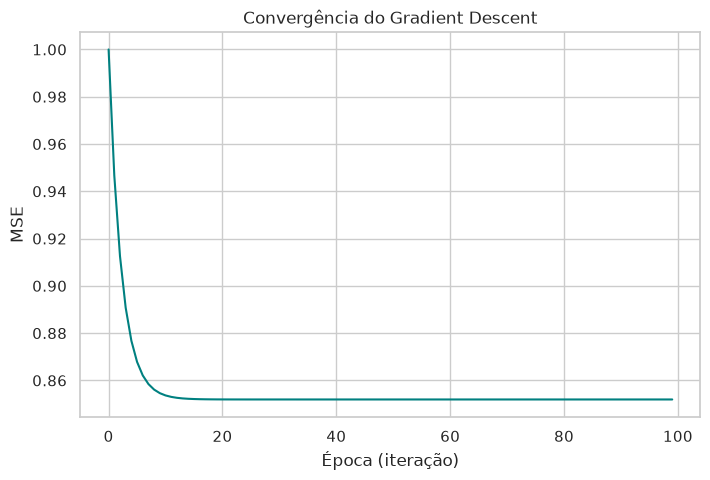

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history, color="teal")
plt.xlabel("Época (iteração)")
plt.ylabel("MSE")
plt.title("Convergência do Gradient Descent")
plt.show()


### A reta aprendida

Agora desenhamos a reta que o modelo encontrou. Como treinamos sobre $x$
**normalizado**, convertemos a grade de $x$ para a escala original só na hora de plotar.


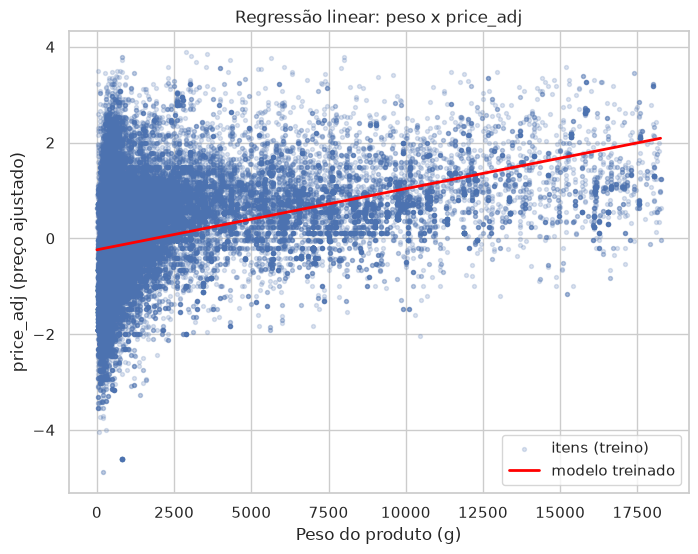

In [20]:
x_grid = np.linspace(x_train.min(), x_train.max(), 100)
x_grid_n = (x_grid - x_mean) / x_std
y_grid = predict(x_grid_n, w, b)

plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, s=8, alpha=0.2, label="itens (treino)")
plt.plot(x_grid, y_grid, color="red", linewidth=2, label="modelo treinado")

plt.xlabel("Peso do produto (g)")
plt.ylabel("price_adj (preço ajustado)")
plt.title("Regressão linear: peso x price_adj")
plt.legend()
plt.show()


### O mesmo modelo com Scikit-Learn

Acabamos de construir o mecanismo **do zero**. Agora veja como a biblioteca
**Scikit-Learn** faz o mesmo trabalho em poucas linhas.


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_n.reshape(-1, 1), y_train)

print(f"Scikit-Learn -> w = {model.coef_[0]:.4f} | b = {model.intercept_:.4f}")
print(f"Nós (NumPy)  -> w = {w:.4f} | b = {b:.4f}")


Scikit-Learn -> w = 0.3848 | b = 0.0000
Nós (NumPy)  -> w = 0.3848 | b = 0.0000


Os valores são **praticamente iguais**: confirmamos que o Gradient Descent chegou
ao mesmo lugar que a solução "pronta" da biblioteca — e agora sabemos o que existe
por trás do `model.fit(...)`.


### Avaliação e diagnóstico do modelo

Treinar não basta: precisamos medir o desempenho no **conjunto de teste** (dados que o
modelo **nunca viu**), para saber se ele **generaliza**.

Vamos usar três métricas:

- **MSE** — erro quadrático médio (pune erros grandes);
- **MAE** (*mean absolute error*) — erro médio em R$, mais fácil de interpretar;
- **R²** — fração da variação de $y$ explicada pelo modelo (1 = perfeito; 0 = tão bom
  quanto prever sempre a média).


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred_test = predict(x_test_n, w, b)

print(f"MSE (em price_adj): {compute_mse(y_test, y_pred_test):.4f}")
print(f"MAE (em price_adj): {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"R²  (em price_adj): {r2_score(y_test, y_pred_test):.3f}")

# Extra: voltando para R$ (invertendo a transformação) para interpretar o erro no mundo real.
price_pred_rs = pt.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()
print(f"\nMAE em R$ (após inverter a transformação): {mean_absolute_error(price_test, price_pred_rs):.2f}")


MSE (em price_adj): 0.8427
MAE (em price_adj): 0.7211
R²  (em price_adj): 0.141

MAE em R$ (após inverter a transformação): 70.31


### Diagnóstico pelos resíduos

Se o modelo estivesse perfeito, os resíduos seriam **ruído aleatório** em torno de
zero, sem padrão. Um **padrão** nos resíduos indica que a reta não captura tudo.


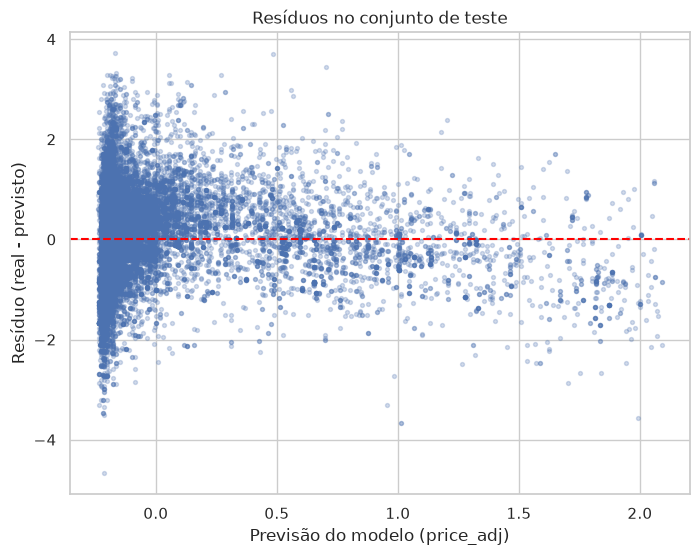

In [23]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, s=8, alpha=0.25)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Previsão do modelo (price_adj)")
plt.ylabel("Resíduo (real - previsto)")
plt.title("Resíduos no conjunto de teste")
plt.show()


### Síntese da Aula 1

Hoje nós:

- entendemos o **fluxo** de um projeto de dados (coleta -> limpeza -> EDA -> modelo);
- aplicamos a transformação **Yeo-Johnson** no `price`, gerando `price_adj`
  (**apenas para simplificar a aula**);
- definimos a regressão linear: $\hat{y} = w\,x + b$;
- escrevemos a função de custo **MSE**;
- usamos a **derivada/gradiente** para aprender com **Gradient Descent**;
- implementamos tudo **do zero em NumPy** e comparamos com o **Scikit-Learn**;
- avaliamos e **diagnosticamos** o modelo (MSE, MAE, R², resíduos).


### Próximos passos

- Faça os **exercícios da Aula 1** para praticar outros cenários.
- Quer aprofundar a matemática? Veja `material-auxiliar/` (Cálculo, Álgebra Linear, Estatística).
- Na **Aula 2**: **classificação** e a ponte para **redes neurais** e **IA**.
